# Where does the extra low cloud in the KENDA-CH1 analysis come from?

## The problem

Total cloud cover from ICON-CH1 is biased too cloudy in the first hours of each forecast. Verified
against Swiss stations over autumn, the bias is about **+0.6 octa at lead time 1 h**, settling to
about **+0.15 octa by lead time 24 h**, decaying over roughly 4-6 hours.

The counter-intuitive part: the short-lead forecast is *better* on every other score = lower mean
absolute error, lower error standard deviation, higher correlation. Only the **bias** is worse. The
assimilation puts cloud in the right places at the right times while overdoing the amount.

This notebook asks **where in the hourly assimilation cycle the extra cloud enters**, using two
experiments that differ in exactly one setting:

- **801**: reference. Screen-level temperature and humidity (`T_2M`, `RH_2M`) are assimilated.
- **802**: identical in every other respect, with `T_2M` and `RH_2M` withheld.

Both are driven by the same initial and boundary conditions, so any difference between them is
attributable to that one setting.

## The files, and what each represents

Every hour the cycle repeats. The files it leaves behind are the stages of that loop:

| file | stage | valid at |
|---|---|---|
| `lff(T)` | **background**; the model's own 1 h forecast from the previous cycle, before new observations are used | T |
| `inc(T)` | **increment**; the correction derived from comparing background against observations. Corrections only, not a state | T |
| `lff(T)+inc(T)` | **analysis before settling** (the raw analysis, identical to the archived `laf(T)`) | T |
| `iaf(T)` | **analysis after settling**; the same increment fed in gradually over a 10-minute window rather than at once. The next forecast starts from this | T |
| `lff(T+1)` | **background of the next cycle**; one hour of model integration on from `iaf(T)` | T+1 |

The gradual-insertion window runs from T-5 min to T+5 min, centred on T. So `iaf(T)` already
contains about 10 minutes of model evolution on top of the increment, and the forecast producing
`lff(T+1)` is still being nudged for its first 5 of 60 minutes.

## The three steps this separates

```
lff(T) ──increment──▶ lff(T)+inc(T) ──settling──▶ iaf(T) ──one free hour──▶ lff(T+1)
        (no model)                  (~10 min model)          (~1 h model)
```

| step | computed as | model content |
|---|---|---|
| increment | `inc(T)` | **none**; purely observation-driven |
| settling | `iaf(T) - lff(T) - inc(T)` | gradual insertion + ~10 min |
| one free hour | `lff(T+1) - iaf(T)` | ~1 h |

**Sign convention throughout: positive means more cloud, more moisture, warmer.**

## What this can and cannot answer

- **Cloud cover cannot be attributed cleanly.** It is *diagnosed*; computed from temperature,
  humidity and cloud water when needed, never analysed. There is no cloud-cover increment, so the
  earliest cloud-cover number after assimilation is `iaf(T)`, which already contains model evolution.
- **Temperature, water vapour and cloud water can.** These are what the cloud-cover scheme is built
  from, and all three are in `inc`, so the split above is exact for them. Mechanism arguments should
  be made on these and then related to cloud cover.
- **Cloud ice is untouched by the assimilation**; excluded both when the analysis is written and
  when the model reads it. Any ice-cloud change is model response by construction.
- **No observations enter this notebook.** It can show that assimilation adds cloud; it cannot say
  whether that is right. That needs the analysis verified against station observations.

## Plotting conventions used throughout

- **Colour identifies the experiment** (801 vs 802) and never anything else.
- **Line style identifies the file**, and is the same style for both experiments.
- Legends always name the file (`lff(T)`, `inc(T)`, `iaf(T)`, `lff(T+1)`) alongside its plain-language
  meaning, so a panel can be read without referring back to this text.
- Every horizontal map carries country borders.
- Every title states the period and the number of cycles included.


## 0. Setup

In [18]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"  # must be set before importing earthkit.data

import pickle
from datetime import datetime, timedelta
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import eccodes            # before earthkit.data, so the native libraries resolve correctly
import earthkit.data as ekd

SAVE_FIGURES = False     # write PNGs to OUTPUT_DIR
SHOW_FIGURES = True     # also draw them inline below each cell

if SAVE_FIGURES and not SHOW_FIGURES:
    matplotlib.use("Agg")

OUTPUT_DIR = Path("./figures/spindown_decomposition")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish(fig, name):
    """Save a figure and/or draw it inline. Closing before showing gives a blank cell."""
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

In [19]:
# ============================== what to analyse ==============================
EXP_IDS = ["801", "802"]
BASE_DIR_TMPL = "/store_new/mch/msopr/jdelbeke/ICON_TST/{exp}"
YEAR_SUFFIX = "25"

# Date range. Everything below is computed from exactly these cycles.
# Available on disk for both experiments: 2025-10-04 01 UTC .. 2025-10-10 00 UTC.
# The end must leave lff(T+1) available, so it cannot exceed 2025-10-10 00 UTC.
DATE_START = datetime(2025, 10, 4, 1)
DATE_END = datetime(2025, 10, 10, 0)

# Take every Nth cycle. 1 = every hour (full period). Raise it for a quick pass:
# 3 keeps full diurnal coverage at a third of the cost, 6 is a fast smoke test.
CYCLE_STRIDE = 1

CYCLE_TIMES = pd.date_range(DATE_START, DATE_END, freq="1h").to_pydatetime().tolist()[::CYCLE_STRIDE]

# Cycles are independent, so section 2 reads them in parallel. Each worker holds one
# cycle at a time (a few hundred MB); lower this on a busy login node, and note that
# tracebacks are clearer with 1.
N_WORKERS = 8

# Analysis domain: a box round Switzerland. Every average and every distribution
# below is taken over these grid cells, so all numbers refer to the same region.
ANALYSIS_BOX = dict(lon=(5.9, 10.6), lat=(45.8, 47.9))
# Slightly wider view for the maps, so the borders give context around the edges.
MAP_BOX = dict(lon=(5.3, 11.2), lat=(45.4, 48.3))

# Lowest model level. ICON-CH1 has 80 layers described by 81 interfaces (HHL), so the
# layer touching the ground is level 80, not 81.
GROUND_LEVEL = 80
# Levels kept for the profiles and the vertical section: ground up to the mid troposphere.
LEVELS_OF_INTEREST = list(range(40, 81))

# Vertical section. Payerne must lie exactly on it, so the line is built as the great
# circle through Payerne and St. Gallen, extended back past Payerne to reach Lake Geneva.
# A straight Geneva -> St. Gallen line would miss Payerne by about 29 km.
PAYERNE = (46.8123, 6.9422)       # radiosonde site; (lat, lon)
SECTION_EAST = (47.4200, 9.3700)  # St. Gallen
SECTION_WEST_KM = 65.0            # how far back past Payerne the section starts
N_TRANSECT = 300
SECTION_ZTOP = 5000.0        # top of the vertical section [m above sea level]

print(f"{len(CYCLE_TIMES)} cycles per experiment, "
      f"{CYCLE_TIMES[0]:%Y-%m-%d %H} UTC to {CYCLE_TIMES[-1]:%Y-%m-%d %H} UTC"
      f"{'' if CYCLE_STRIDE == 1 else f', every {CYCLE_STRIDE}th hour'}")

144 cycles per experiment, 2025-10-04 01 UTC to 2025-10-10 00 UTC


In [20]:
# ============================ plotting conventions ============================
# Colour = experiment. Never used for anything else.
EXP_COLOUR = {"801": "#0072B2", "802": "#D55E00"}

# Line style = file. Identical styles for both experiments.
STAGES = ["lff", "laf", "iaf", "lff1"]
STAGE_STYLE = {
    "lff":  ("--",  "lff(T) = first guess"),
    "laf":  ("-",   "lff(T)+inc(T) = analysis, before settling"),
    "iaf":  ("-.",  "iaf(T) = analysis, after settling"),
    "lff1": (":",   "lff(T+1) = background, next cycle"),
}
TERMS = ["d_letkf", "d_settle", "d_free"]
TERM_STYLE = {
    "d_letkf":  ("-",  "inc(T) = assimilation increment"),
    "d_settle": ("--", "iaf(T) - lff(T) - inc(T) = settling"),
    "d_free":   (":",  "lff(T+1) - iaf(T) = one free hour"),
}

LEVEL_LABEL = "model level   (80 = ground, 40 = mid troposphere)"


def period_tag(n_cycles):
    """Consistent period-and-sample-size string for every title."""
    return (f"{DATE_START:%d %b} - {DATE_END:%d %b %Y}, {n_cycles} cycles per experiment"
            + ("" if CYCLE_STRIDE == 1 else f" (every {CYCLE_STRIDE}th hour)"))


def style_legend(ax, styles, exps=EXP_IDS, **kw):
    """Two-part legend: experiments (coloured) first, then the file line styles (grey)."""
    handles = [Line2D([], [], color=EXP_COLOUR[e], ls="-", lw=2.6, label=f"experiment {e}")
               for e in exps]
    handles += [Line2D([], [], color="0.25", ls=s, lw=1.6, label=lab) for s, lab in styles.values()]
    ax.legend(handles=handles, **kw)


def orient_vertical(ax, level):
    """Ground at the bottom of the axis, model top at the top.

    An explicit set_ylim, not invert_yaxis(): invert_yaxis() *toggles*, and with
    sharey=True all panels share one axis, so calling it once per panel flips an even
    number of times and silently lands back upside down.
    """
    ax.set_ylim(np.max(level), np.min(level))


def add_borders(ax):
    """Country borders, coastlines and lakes on a map axis."""
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.7, edgecolor="k")
    ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.5, edgecolor="k")
    ax.add_feature(cfeature.LAKES.with_scale("10m"), facecolor="none",
                   edgecolor="0.35", linewidth=0.4)


### Reading the files

Each of these GRIB files holds 1200-1500 messages: roughly 105 variables, most of them on all 80
model levels. A cycle needs four of those variables on 41 levels, so anything that touches the file
as a whole throws away almost everything it reads.

`Grib` therefore indexes a file with a **headers-only** pass, recording where each message begins
without decoding any values, and then reads only the messages asked for by seeking to their offsets.
The index is cached on disk, so repeat runs skip even that pass. Measured on one 1.2 GB increment
file: earthkit's own scan plus a four-variable read costs about 50 s and 4.5 GB of I/O, against about
3 s and 0.5 GB here, for bit-identical values.

In [21]:
def file_path(exp_id, kind, time):
    """kind: "lff"/"iff" (first-guess archive) or "inc"/"iaf"/"laf" (analysis archive)."""
    base = BASE_DIR_TMPL.format(exp=exp_id)
    sub = ("FG" if kind in ("lff", "iff") else "ANA") + YEAR_SUFFIX
    return os.path.join(base, sub, "det", f"{kind}{time:%Y%m%d%H}")


CACHE_DIR = Path(f"/scratch/mch/{os.environ['USER']}/spindown_grib_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def build_index(path):
    """shortName -> [(level, byte offset, byte length), ...], sorted by level.

    A headers-only pass: ecCodes is asked for each message's metadata but never for its
    values, so all this records is where every message sits in the file. Values are read
    later by seeking straight to the few messages actually wanted.

    This replaces earthkit's own scan (`from_source(...).to_fieldlist()` followed by
    `.metadata("shortName")`), which decodes every message in full and so reads the whole
    file: about 14 s and a 3 GB read per file, against about 1.3 s here.
    """
    index = {}
    with open(path, "rb") as f:
        while True:
            h = eccodes.codes_grib_new_from_file(f, headers_only=True)
            if h is None:
                break
            index.setdefault(eccodes.codes_get(h, "shortName"), []).append(
                (eccodes.codes_get_long(h, "level"),
                 eccodes.codes_get_message_offset(h),
                 eccodes.codes_get_long(h, "totalLength")))
            eccodes.codes_release(h)
    for entries in index.values():
        entries.sort()          # by level, so a profile comes back ground-up consistently
    return index


def load_index(path):
    """build_index, cached on disk so repeat runs skip the header pass altogether.

    These archive files are immutable, so the key is (name, size, mtime): a regenerated
    file invalidates its own entry instead of returning a stale index.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    stat = os.stat(path)
    cached = CACHE_DIR / f"{Path(path).name}_{stat.st_size}_{stat.st_mtime_ns}.pkl"
    if cached.exists():
        with open(cached, "rb") as fh:
            return pickle.load(fh)
    index = build_index(path)
    tmp = cached.with_suffix(f".tmp{os.getpid()}")   # unique + atomic: workers run in parallel
    with open(tmp, "wb") as fh:
        pickle.dump(index, fh, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, cached)
    return index


_grid = None


def grid_lonlat(path):
    """Cell longitudes and latitudes, via earthkit once and cached thereafter.

    ecCodes will not expand the coordinates of this unstructured (triangular) grid - the
    "latitudes"/"longitudes" keys raise KeyValueNotFoundError - so one field has to go
    through earthkit. Every file in both experiments shares the same grid, so this runs
    once per session, and once ever per machine thanks to the .npz.
    """
    global _grid
    if _grid is not None:
        return _grid
    npz = CACHE_DIR / "icon_grid_lonlat.npz"
    if npz.exists():
        z = np.load(npz)
        _grid = (z["lon"], z["lat"])
    else:
        xa = ekd.from_source("file", path).to_fieldlist()[0].to_xarray()
        _grid = (xa["longitude"].values, xa["latitude"].values)
        np.savez(npz, lon=_grid[0], lat=_grid[1])
    return _grid


class Grib:
    """One GRIB file, indexed by variable name, decoding only the messages asked for.

    Each ICON file here carries 1200-1500 messages over ~105 variables; a cycle wants four
    variables on 41 of the 80 levels. Reading by message offset keeps the cost proportional
    to that rather than to the size of the file.
    """

    def __init__(self, path):
        self.path = path
        self.index = load_index(path)

    def _read(self, entries):
        values = []
        with open(self.path, "rb") as f:
            for _, offset, length in entries:
                f.seek(offset)
                h = eccodes.codes_new_from_message(f.read(length))
                values.append(eccodes.codes_get_values(h))
                eccodes.codes_release(h)
        return np.array([e[0] for e in entries]), np.stack(values)

    def profile(self, short_name, levels=None):
        """Multi-level field -> (levels, array of shape (n_levels, n_cells)).

        `levels` filters before anything is decoded, which is the whole point: decoding all
        80 levels and then discarding 39 of them doubled both the read and the memory.
        """
        entries = self.index[short_name]
        if levels is not None:
            want = {int(lev) for lev in levels}
            entries = [e for e in entries if e[0] in want]
        return self._read(entries)

    def field(self, short_name):
        """Single-level field -> values."""
        return self._read(self.index[short_name][:1])[1][0]

    @property
    def lonlat(self):
        return grid_lonlat(self.path)


def in_box(lon, lat, box):
    return ((lon >= box["lon"][0]) & (lon <= box["lon"][1]) &
            (lat >= box["lat"][0]) & (lat <= box["lat"][1]))

### What the increment does and does not contain

The increment carries temperature, water vapour, cloud **water**, wind, pressure and soil moisture =
but **no cloud fraction and no cloud ice**. Both omissions are configuration choices, not gaps in
the archive: cloud ice is excluded when the analysis is written and ignored again when the model
reads it. Therefore any change in cloud *cover* between background and analysis is a downstream
response to the temperature, humidity and cloud-water corrections, and any change in cloud *ice* is
model response only.

One further detail matters for interpretation. Where the background already holds cloud water, a
cloud-water correction is added to cloud water as expected. Where the background is cloud-free, the
same correction is added to **water vapour** instead = a route by which a correction intended as
cloud arrives as invisible moisture that the model may condense during the first timesteps.


## 1. Diurnal cycle of cloud cover over Switzerland

The question this answers: at each hour of the day, does the analysis hold more cloud than the
background it started from, and by how much?

Each box summarises the distribution of cloud cover over the grid cells inside the Swiss box,
pooled across every day of the period at that hour. The spread therefore reflects both how variable
cloud is across the country and how much it varied from day to day. Boxes show the median and
quartiles, whiskers the 5th to 95th percentile; the many cells at exactly 0% or 100% are why the
whiskers often reach the limits.

Two boxes per hour: **`lff(T)` background** (unfilled, dashed edge) and **`iaf(T)` analysis** (filled,
solid edge). Reading left to right gives the diurnal cycle; comparing the pair within an hour gives
what the assimilation did at that hour.

`CLCT` is total cloud cover, `CLCL` is low cloud (ground to about 2 km); the band where the earlier
results concentrate.


In [22]:
CLOUD_VARS = ["CLCT", "CLCL"]
N_BOX_SAMPLE = 5000     # grid cells sampled per cycle; enough for stable quartiles


def cloud_samples(exp_id, t):
    """Cloud cover inside the analysis box for background and analysis at one cycle."""
    lff = Grib(file_path(exp_id, "lff", t))
    iaf = Grib(file_path(exp_id, "iaf", t))
    lon, lat = lff.lonlat
    mask = in_box(lon, lat, ANALYSIS_BOX)
    idx_box = np.flatnonzero(mask)
    rng = np.random.default_rng(int(t.timestamp()) % (2**31))
    take = rng.choice(idx_box, size=min(N_BOX_SAMPLE, idx_box.size), replace=False)

    out = {"exp": exp_id, "time": t, "hour": t.hour, "n_box_cells": int(idx_box.size)}
    for var in CLOUD_VARS:
        v_lff, v_iaf = lff.field(var), iaf.field(var)
        out[(var, "lff", "sample")] = v_lff[take]
        out[(var, "iaf", "sample")] = v_iaf[take]
        out[(var, "lff", "mean")] = float(np.nanmean(v_lff[mask]))
        out[(var, "iaf", "mean")] = float(np.nanmean(v_iaf[mask]))
    return out


def cloud_samples_safe(exp_id, t):
    try:
        return cloud_samples(exp_id, t)
    except Exception as e:
        print(f"  skipped {exp_id} {t:%Y-%m-%d %H}: {e}")
        return None


jobs = [(e, t) for e in EXP_IDS for t in CYCLE_TIMES]
print(f"reading {len(jobs)} cycle-experiment combinations (2 files each, 2 messages per file)...")
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    futures = [ex.submit(cloud_samples_safe, e, t) for e, t in jobs]
    cloud_records = [f.result() for f in futures]
cloud_records = [r for r in cloud_records if r is not None]

n_cycles_cloud = len({r["time"] for r in cloud_records if r["exp"] == EXP_IDS[0]})
print(f"{len(cloud_records)} loaded; {n_cycles_cloud} cycles per experiment; "
      f"{cloud_records[0]['n_box_cells']} grid cells inside the Swiss box")

# domain-mean time series, for the overview figure
cloud_means = pd.DataFrame([
    {"exp": r["exp"], "time": r["time"], "hour": r["hour"],
     **{f"{v}_{s}": r[(v, s, "mean")] for v in CLOUD_VARS for s in ("lff", "iaf")}}
    for r in cloud_records]).sort_values(["exp", "time"]).reset_index(drop=True)
cloud_means.to_csv(OUTPUT_DIR / "cloud_cover_means.csv", index=False)

reading 288 cycle-experiment combinations (2 files each, 2 messages per file)...
288 loaded; 144 cycles per experiment; 80876 grid cells inside the Swiss box


In [23]:
# Pool the per-cycle samples by hour, keeping experiments and stages separate.
pooled = {}
for exp_id in EXP_IDS:
    for var in CLOUD_VARS:
        for stage in ("lff", "iaf"):
            for h in range(24):
                chunks = [r[(var, stage, "sample")] for r in cloud_records
                          if r["exp"] == exp_id and r["hour"] == h]
                pooled[(exp_id, var, stage, h)] = (np.concatenate(chunks) if chunks
                                                   else np.array([]))

hours_present = sorted({r["hour"] for r in cloud_records})
n_days = {h: sum(1 for r in cloud_records if r["exp"] == EXP_IDS[0] and r["hour"] == h)
          for h in hours_present}
print(f"hours covered: {hours_present[0]:02d}-{hours_present[-1]:02d} UTC, "
      f"{min(n_days.values())}-{max(n_days.values())} days per hour")


hours covered: 00-23 UTC, 6-6 days per hour


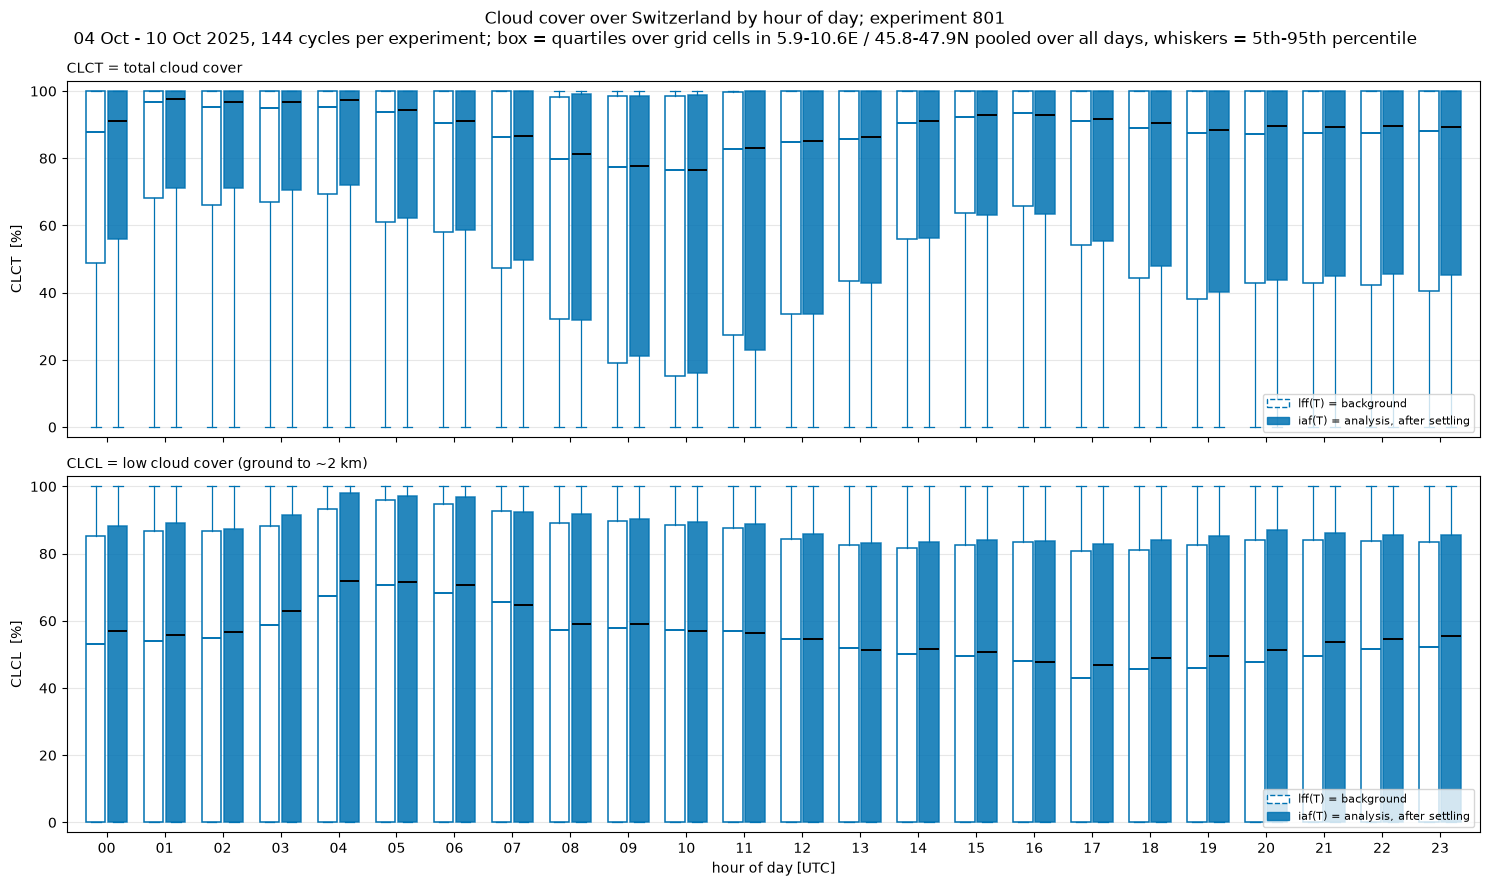

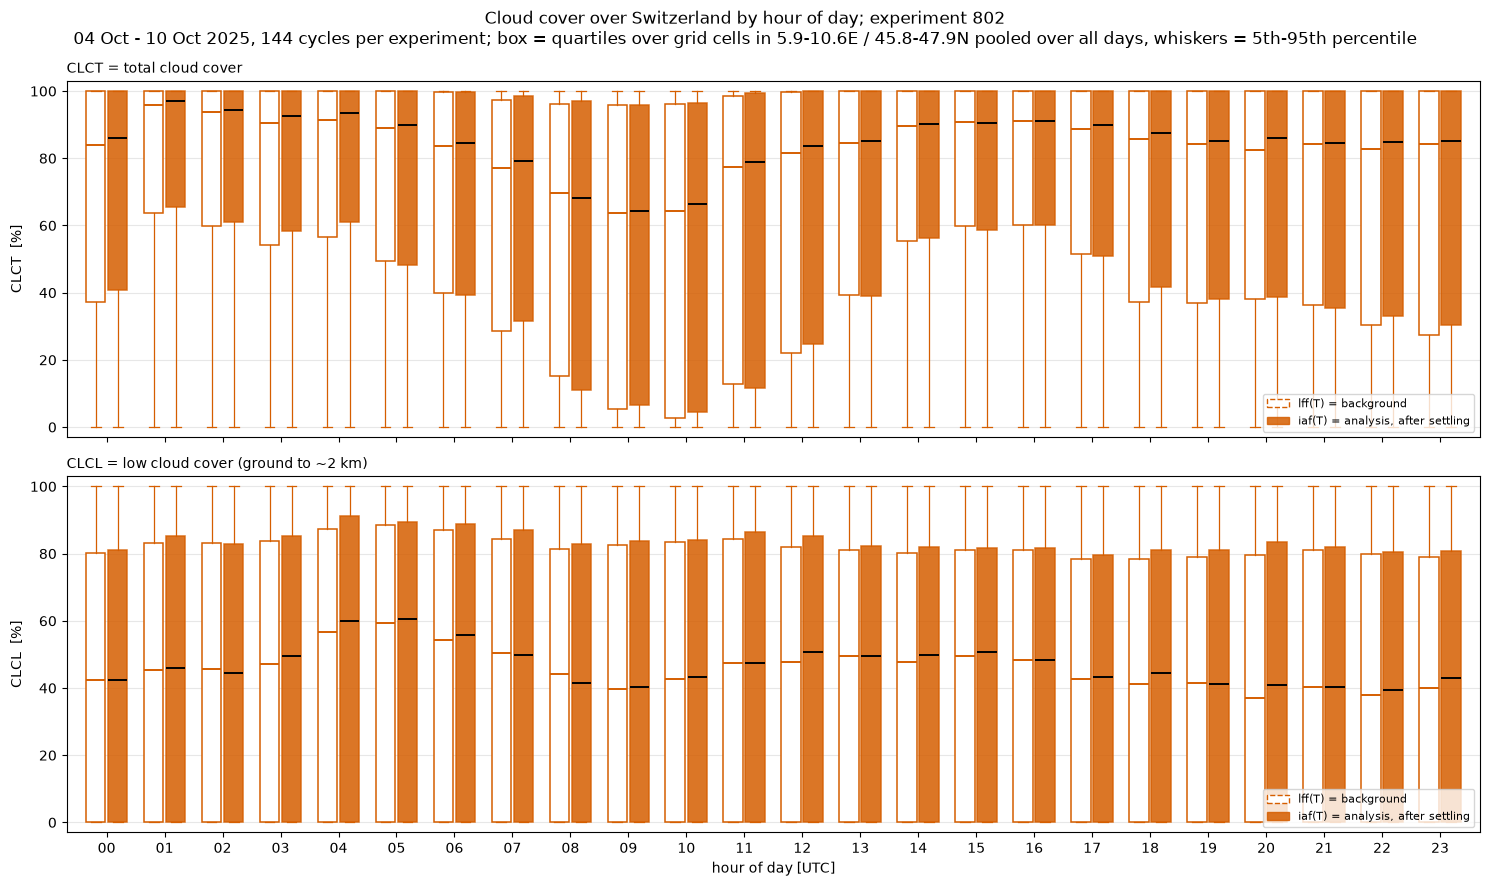

In [24]:
VAR_LONG = {"CLCT": "total cloud cover", "CLCL": "low cloud cover (ground to ~2 km)"}

for exp_id in EXP_IDS:
    fig, axes = plt.subplots(len(CLOUD_VARS), 1, figsize=(15, 9), sharex=True)
    colour = EXP_COLOUR[exp_id]

    for ax, var in zip(axes, CLOUD_VARS):
        for h in hours_present:
            for stage, offset in (("lff", -0.19), ("iaf", +0.19)):
                data = pooled[(exp_id, var, stage, h)]
                if data.size == 0:
                    continue
                filled = stage == "iaf"
                ax.boxplot(
                    [data], positions=[h + offset], widths=0.34, whis=(5, 95),
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor=colour if filled else "white",
                                  edgecolor=colour, linewidth=1.1,
                                  linestyle="-" if filled else "--",
                                  alpha=0.85 if filled else 1.0),
                    medianprops=dict(color="k" if filled else colour, linewidth=1.4),
                    whiskerprops=dict(color=colour, linewidth=0.9),
                    capprops=dict(color=colour, linewidth=0.9))
        ax.set_ylabel(f"{var}  [%]")
        ax.set_title(f"{var} = {VAR_LONG[var]}", fontsize=10, loc="left")
        ax.grid(alpha=0.3, axis="y")
        ax.set_ylim(-3, 103)
        ax.legend(handles=[
            Patch(facecolor="white", edgecolor=colour, linestyle="--",
                  label="lff(T) = background"),
            Patch(facecolor=colour, edgecolor=colour, alpha=0.85,
                  label="iaf(T) = analysis, after settling")], loc="lower right", fontsize=8)

    axes[-1].set_xticks(hours_present)
    axes[-1].set_xticklabels([f"{h:02d}" for h in hours_present])
    axes[-1].set_xlabel("hour of day [UTC]")
    plt.suptitle(f"Cloud cover over Switzerland by hour of day; experiment {exp_id}"
                 f"\n{period_tag(n_cycles_cloud)}; "
                 f"box = quartiles over grid cells in {ANALYSIS_BOX['lon'][0]}-"
                 f"{ANALYSIS_BOX['lon'][1]}E / {ANALYSIS_BOX['lat'][0]}-{ANALYSIS_BOX['lat'][1]}N "
                 f"pooled over all days, whiskers = 5th-95th percentile")
    plt.tight_layout()
    finish(fig, f"diurnal_boxplots_{exp_id}.png")


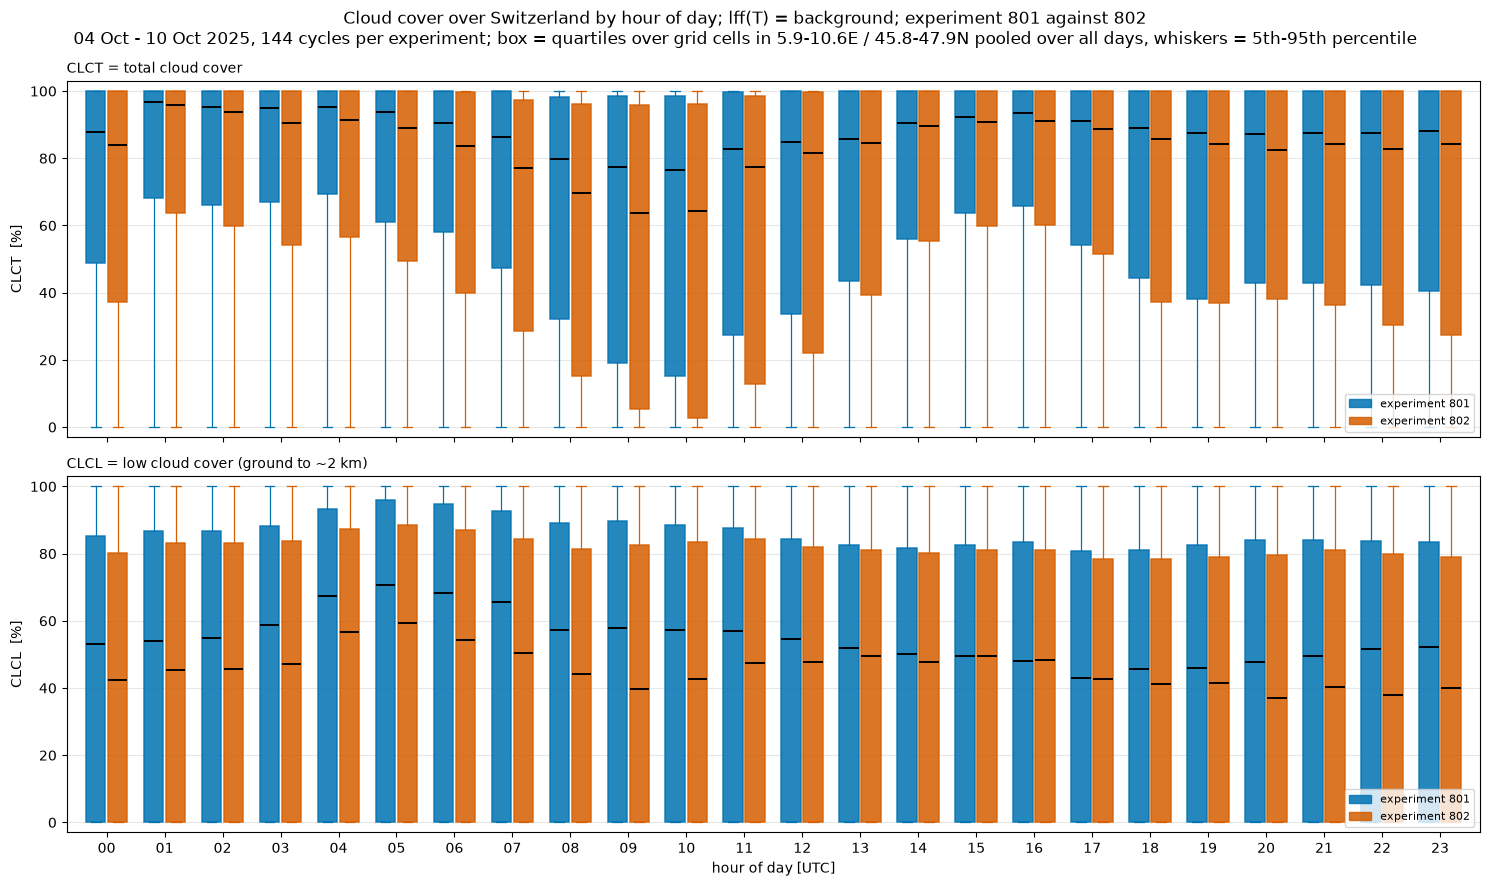

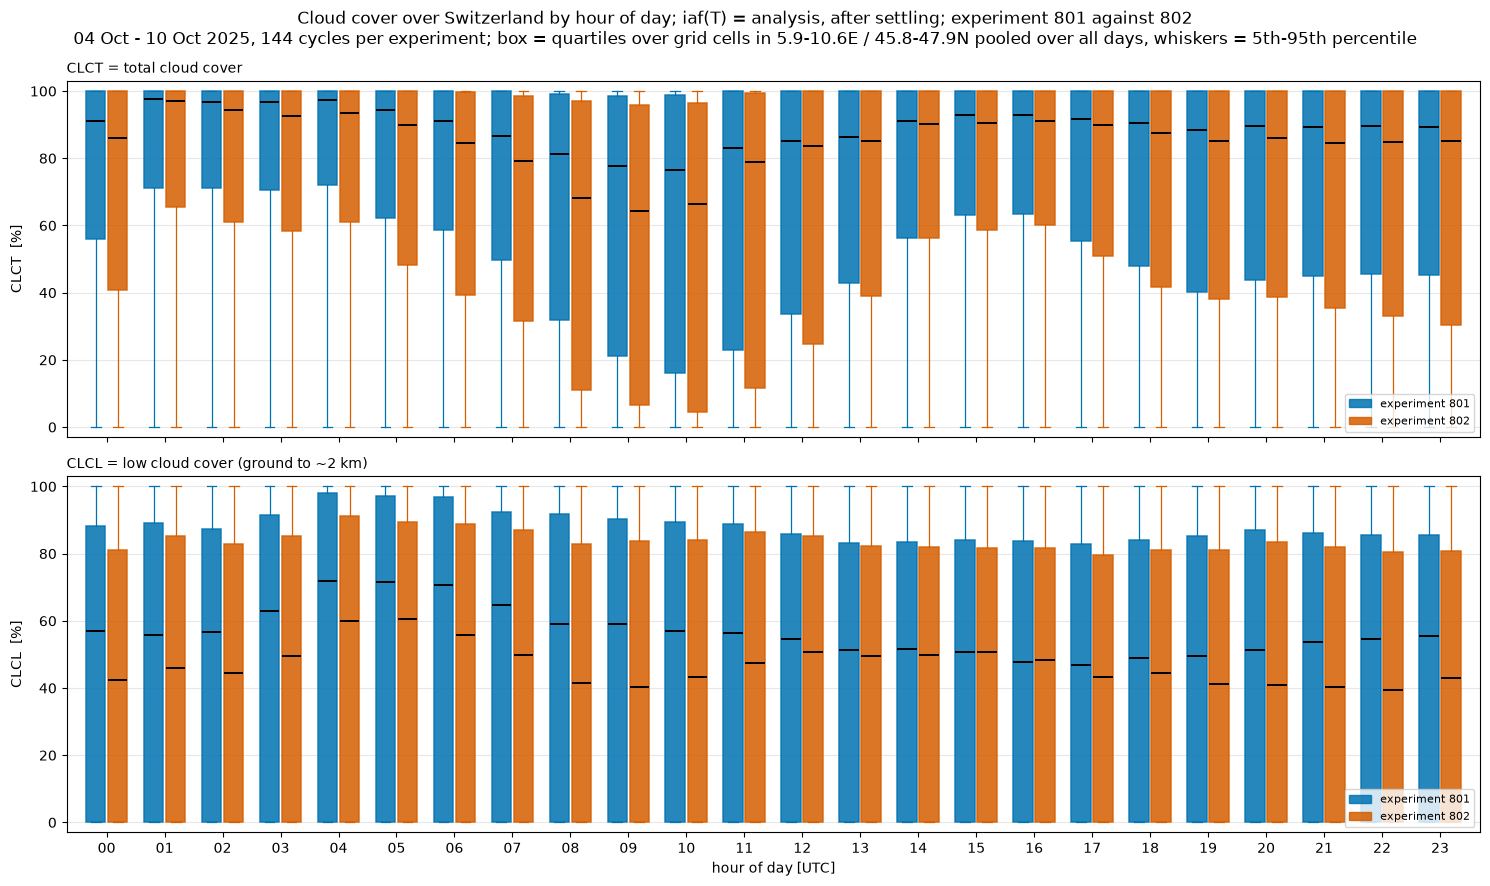

In [25]:
# Direct comparison of the two experiments in one panel, one figure per file.
STAGE_LABEL = {"lff": "lff(T) = background", "iaf": "iaf(T) = analysis, after settling"}

for stage in ("lff", "iaf"):
    fig, axes = plt.subplots(len(CLOUD_VARS), 1, figsize=(15, 9), sharex=True)
    for ax, var in zip(axes, CLOUD_VARS):
        for h in hours_present:
            for exp_id, offset in zip(EXP_IDS, (-0.19, +0.19)):
                data = pooled[(exp_id, var, stage, h)]
                if data.size == 0:
                    continue
                colour = EXP_COLOUR[exp_id]
                ax.boxplot(
                    [data], positions=[h + offset], widths=0.34, whis=(5, 95),
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor=colour, edgecolor=colour, linewidth=1.1, alpha=0.85),
                    medianprops=dict(color="k", linewidth=1.4),
                    whiskerprops=dict(color=colour, linewidth=0.9),
                    capprops=dict(color=colour, linewidth=0.9))
        ax.set_ylabel(f"{var}  [%]")
        ax.set_title(f"{var} = {VAR_LONG[var]}", fontsize=10, loc="left")
        ax.grid(alpha=0.3, axis="y")
        ax.set_ylim(-3, 103)
        ax.legend(handles=[Patch(facecolor=EXP_COLOUR[e], edgecolor=EXP_COLOUR[e],
                                 alpha=0.85, label=f"experiment {e}") for e in EXP_IDS],
                  loc="lower right", fontsize=8)
    axes[-1].set_xticks(hours_present)
    axes[-1].set_xticklabels([f"{h:02d}" for h in hours_present])
    axes[-1].set_xlabel("hour of day [UTC]")
    plt.suptitle(f"Cloud cover over Switzerland by hour of day; {STAGE_LABEL[stage]}; "
                 f"experiment 801 against 802"
                 f"\n{period_tag(n_cycles_cloud)}; "
                 f"box = quartiles over grid cells in {ANALYSIS_BOX['lon'][0]}-"
                 f"{ANALYSIS_BOX['lon'][1]}E / {ANALYSIS_BOX['lat'][0]}-{ANALYSIS_BOX['lat'][1]}N "
                 f"pooled over all days, whiskers = 5th-95th percentile")
    plt.tight_layout()
    finish(fig, f"diurnal_boxplots_801_vs_802_{stage}.png")


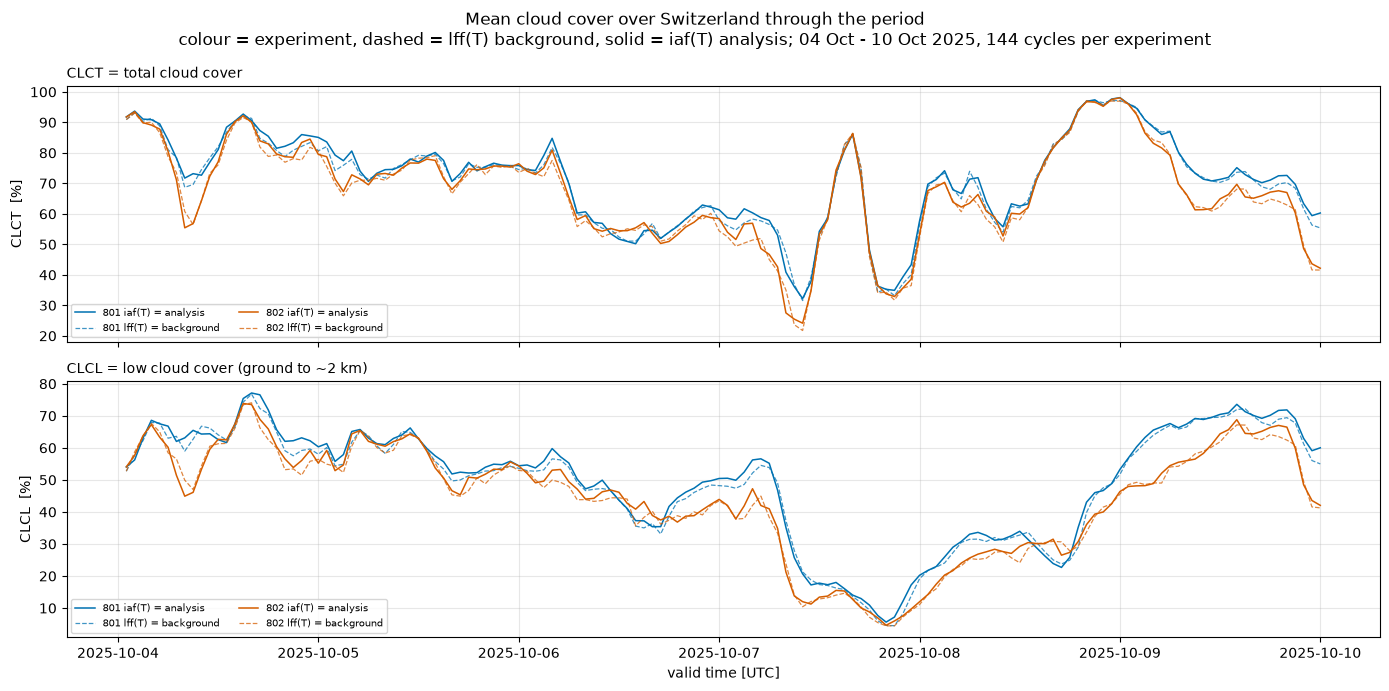

In [26]:
# Difference between the two experiments through the period, as a sanity view of when they diverge.
fig, axes = plt.subplots(len(CLOUD_VARS), 1, figsize=(14, 7), sharex=True)
for ax, var in zip(axes, CLOUD_VARS):
    for exp_id in EXP_IDS:
        sub = cloud_means[cloud_means["exp"] == exp_id]
        ax.plot(sub["time"], sub[f"{var}_iaf"], "-", color=EXP_COLOUR[exp_id], lw=1.1,
                label=f"{exp_id} iaf(T) = analysis")
        ax.plot(sub["time"], sub[f"{var}_lff"], "--", color=EXP_COLOUR[exp_id], lw=0.9,
                alpha=0.75, label=f"{exp_id} lff(T) = background")
    ax.set_ylabel(f"{var}  [%]")
    ax.set_title(f"{var} = {VAR_LONG[var]}", fontsize=10, loc="left")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, ncol=2)
axes[-1].set_xlabel("valid time [UTC]")
plt.suptitle(f"Mean cloud cover over Switzerland through the period\n"
             f"colour = experiment, dashed = lff(T) background, solid = iaf(T) analysis; "
             f"{period_tag(n_cycles_cloud)}")
plt.tight_layout()
finish(fig, "cloud_cover_timeseries.png")


## 2. Temperature, water vapour and cloud water through the cycle

Cloud cover on its own cannot identify a cause: it is a diagnosed quantity, two steps removed from
anything the assimilation touches. Temperature (`T`), water vapour (`QV`) and cloud water (`QC`) are
what the cloud-cover scheme is computed from, and all three are in the increment file, together with
pressure, so relative humidity (`RH`) can be formed at every stage as well. That makes the split into
increment, settling and free hour exact for these variables.

The raw analysis is reconstructed as `lff(T)+inc(T)` rather than read from disk, which is exact to
rounding and saves a file read per cycle. Relative humidity differences are formed by differencing
the relative humidity of each stage, not from the temperature and humidity increments, because
relative humidity is non-linear in both.

This cell also accumulates the mean increment fields used by the cross-sections in section 4, so
those come for free rather than needing a second pass over the data.

**Cost.** Four files per cycle, of which only 41 of 80 levels of four variables are decoded: a few
hundred MB read per cycle, against the ~20 GB a full scan of those same files costs. Cycles are
independent, so they run on `N_WORKERS` processes, and each worker returns only the reduced profiles
rather than its 3-D arrays. The whole period over both experiments takes minutes and a few GB, where
reading full domains serially took hours and about 12 GB. Raise `CYCLE_STRIDE` in section 0 for a
quicker pass.

In [27]:
DIAG_VARS = ["T", "QV", "QC"]
VAR_UNITS = {"T": "K", "QV": "kg/kg", "QC": "kg/kg", "RH": "%"}
PLOT_VARS = DIAG_VARS + ["RH"]


def saturation_qv(T_k, p_pa):
    """Saturation specific humidity from temperature [K] and pressure [Pa] (Tetens, over water)."""
    T_c = T_k - 273.15
    e_s = 611.2 * np.exp(17.62 * T_c / (243.12 + T_c))
    return 0.622 * e_s / np.clip(p_pa - 0.378 * e_s, 1.0, None)


def cycle_states(exp_id, t, sel, levels=LEVELS_OF_INTEREST):
    """The four states and three steps of one cycle, for T, QV, QC and derived RH.

    `sel` comes from load_geometry and fixes which grid cells survive the read: the
    analysis box first, then the transect columns. Subsetting here rather than in the
    caller is what keeps a cycle to a few hundred MB - these same arrays over the full
    1.1M-cell domain came to about 12 GB, which on a shared node meant swapping instead
    of computing.
    """
    keep = sel["keep"]
    lff = Grib(file_path(exp_id, "lff", t))
    inc = Grib(file_path(exp_id, "inc", t))
    iaf = Grib(file_path(exp_id, "iaf", t))
    lff1 = Grib(file_path(exp_id, "lff", t + timedelta(hours=1)))

    def kept(grib, var):
        return grib.profile(var, levels)[1][:, keep]

    out = {}
    for var in DIAG_VARS + ["P"]:
        a_lff, a_inc = kept(lff, var), kept(inc, var)
        a_iaf, a_lff1 = kept(iaf, var), kept(lff1, var)
        out[("lff", var)] = a_lff
        out[("laf", var)] = a_lff + a_inc
        out[("iaf", var)] = a_iaf
        out[("lff1", var)] = a_lff1
        if var != "P":          # pressure is only a stepping stone to RH; its steps are unused
            out[("d_letkf", var)] = a_inc
            out[("d_settle", var)] = a_iaf - a_lff - a_inc
            out[("d_free", var)] = a_lff1 - a_iaf

    for stage in STAGES:
        out[(stage, "RH")] = 100.0 * out[(stage, "QV")] / saturation_qv(out[(stage, "T")],
                                                                       out[(stage, "P")])
    for term, (a, b) in zip(TERMS, [("laf", "lff"), ("iaf", "laf"), ("lff1", "iaf")]):
        out[(term, "RH")] = out[(a, "RH")] - out[(b, "RH")]
    for stage in STAGES:
        del out[(stage, "P")]

    # Layer mass, for the column-integrated water budget. Density is carried only in the
    # analysis file; the layer thicknesses come from load_geometry, being static.
    out["layer_mass"] = kept(iaf, "DEN") * sel["dz"]

    # Ground-level increment over the whole domain, for the maps in section 4. That is one
    # level per variable, so the full domain is affordable here even though it is not for
    # the profiles above.
    for var in DIAG_VARS:
        out[("ground", var)] = inc.profile(var, [GROUND_LEVEL])[1][0]
    return out

In [28]:
def initial_bearing(p0, p1):
    """Initial great-circle bearing from p0 to p1 [degrees from north]."""
    la1, lo1, la2, lo2 = map(np.deg2rad, [p0[0], p0[1], p1[0], p1[1]])
    dlo = lo2 - lo1
    return np.rad2deg(np.arctan2(np.sin(dlo) * np.cos(la2),
                                 np.cos(la1) * np.sin(la2) -
                                 np.sin(la1) * np.cos(la2) * np.cos(dlo)))


def destination(p, bearing_deg, dist_km, R=6371.0):
    """Point reached from p by travelling dist_km along a great circle on the given bearing."""
    la1, lo1 = np.deg2rad(p[0]), np.deg2rad(p[1])
    br, d = np.deg2rad(bearing_deg), dist_km / R
    la2 = np.arcsin(np.sin(la1) * np.cos(d) + np.cos(la1) * np.sin(d) * np.cos(br))
    lo2 = lo1 + np.arctan2(np.sin(br) * np.sin(d) * np.cos(la1),
                           np.cos(d) - np.sin(la1) * np.sin(la2))
    return (float(np.rad2deg(la2)), float(np.rad2deg(lo2)))


def cross_track_km(p0, p1, target, R=6371.0):
    """Perpendicular distance from `target` to the great circle p0 -> p1 [km]."""
    la0, lo0, la3, lo3 = map(np.deg2rad, [p0[0], p0[1], target[0], target[1]])
    d13 = np.arccos(np.clip(np.sin(la0) * np.sin(la3) +
                            np.cos(la0) * np.cos(la3) * np.cos(lo3 - lo0), -1, 1))
    th13 = np.deg2rad(initial_bearing(p0, target))
    th12 = np.deg2rad(initial_bearing(p0, p1))
    return float(abs(np.arcsin(np.sin(d13) * np.sin(th13 - th12)) * R))


def transect_points(p0, p1, n):
    """n points along the great circle from p0 to p1; returns lat, lon, distance [km]."""
    la0, lo0, la1, lo1 = map(np.deg2rad, [p0[0], p0[1], p1[0], p1[1]])
    d = np.arccos(np.clip(np.sin(la0) * np.sin(la1) +
                          np.cos(la0) * np.cos(la1) * np.cos(lo1 - lo0), -1, 1))
    f = np.linspace(0, 1, n)
    A, B = np.sin((1 - f) * d) / np.sin(d), np.sin(f * d) / np.sin(d)
    x = A * np.cos(la0) * np.cos(lo0) + B * np.cos(la1) * np.cos(lo1)
    y = A * np.cos(la0) * np.sin(lo0) + B * np.cos(la1) * np.sin(lo1)
    z = A * np.sin(la0) + B * np.sin(la1)
    return (np.rad2deg(np.arctan2(z, np.sqrt(x ** 2 + y ** 2))),
            np.rad2deg(np.arctan2(y, x)), d * 6371.0 * f)


def _unit_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.column_stack([np.cos(la) * np.cos(lo), np.cos(la) * np.sin(lo), np.sin(la)])


def nearest_cells(lon, lat, lon_t, lat_t):
    """Nearest model cell to each requested point, on the sphere."""
    return cKDTree(_unit_xyz(lat, lon)).query(_unit_xyz(lat_t, lon_t))[1]


# Build the section so Payerne lies on it by construction: walk back from Payerne along
# the reverse of the Payerne -> St. Gallen bearing.
SECTION_WEST = destination(PAYERNE, initial_bearing(PAYERNE, SECTION_EAST) + 180.0,
                           SECTION_WEST_KM)
TRANSECT = (SECTION_WEST, SECTION_EAST)
print(f"section start {SECTION_WEST[0]:.4f}N {SECTION_WEST[1]:.4f}E, "
      f"end {SECTION_EAST[0]:.4f}N {SECTION_EAST[1]:.4f}E")
print(f"Payerne lies {cross_track_km(SECTION_WEST, SECTION_EAST, PAYERNE) * 1000:.1f} m "
      f"off the section line (0 = exactly on it)")


section start 46.5993N 6.1484E, end 47.4200N 9.3700E
Payerne lies 0.0 m off the section line (0 = exactly on it)


In [29]:
# accumulators
state_prof, term_prof = {}, {}          # (exp, stage/term, var) -> list of profiles
sat_frac = {}                           # (exp, stage) -> list of saturated-fraction profiles
budget_rows = []                        # per-cycle column water budget
inc_ground = {}                         # (exp, var) -> running sum, ground level, all cells
inc_section = {}                        # (exp, var) -> running sum along the transect
n_used = {e: 0 for e in EXP_IDS}

lat_t, lon_t, dist_t = transect_points(*TRANSECT, N_TRANSECT)


def load_geometry(exp_id, t, levels=LEVELS_OF_INTEREST):
    """Grid, terrain and layer geometry, plus the cell selection every cycle reuses.

    All of this is static - the grid and the vertical coordinate do not change between
    cycles or between experiments - so it is read once here instead of being recovered
    from the first cycle's arrays.
    """
    lff, iaf = Grib(file_path(exp_id, "lff", t)), Grib(file_path(exp_id, "iaf", t))
    lon, lat = lff.lonlat
    lev = np.array(sorted(levels))
    # Layer L is bounded by HHL interfaces L and L+1, so the layers of interest need one
    # interface more than they have levels.
    _, hhl = iaf.profile("HHL", range(int(lev.min()), int(lev.max()) + 2))
    t_idx = nearest_cells(lon, lat, lon_t, lat_t)
    box_idx = np.flatnonzero(in_box(lon, lat, ANALYSIS_BOX))
    keep = np.concatenate([box_idx, t_idx])     # box cells first, then the transect columns

    return dict(lon=lon, lat=lat, hsurf=lff.field("HSURF"), level=lev,
                z=0.5 * (hhl[:-1] + hhl[1:]),          # layer-centre height [m]
                t_idx=t_idx, n_box=box_idx.size, keep=keep,
                # what a worker needs, and nothing more: the selection and the thicknesses
                # over it, sent once per worker rather than once per cycle
                sel=dict(keep=keep, n_box=box_idx.size,
                         dz=(-np.diff(hhl, axis=0))[:, keep]))


_SEL = None


def _init_worker(sel):
    """Give each worker the cell selection once, at start-up."""
    global _SEL
    _SEL = sel


def cycle_summary(exp_id, t):
    """One cycle reduced to exactly what the figures need, so a worker returns kB not GB."""
    sel = _SEL
    n_box = sel["n_box"]
    box = slice(0, n_box)                       # the transect columns follow the box in `keep`
    st = cycle_states(exp_id, t, sel)

    prof = {(name, var): np.nanmean(st[(name, var)][:, box], axis=1)
            for var in PLOT_VARS for name in STAGES + TERMS}
    sat = {stage: np.nanmean(st[(stage, "RH")][:, box] >= 100.0, axis=1) for stage in STAGES}

    row = dict(exp=exp_id, time=t, hour=t.hour)
    for var in ("QC", "QV"):
        for term in TERMS:
            col = np.nansum(st[(term, var)] * st["layer_mass"], axis=0)
            row[f"{var}_{term}"] = float(np.nanmean(col[box]))

    return dict(exp=exp_id, prof=prof, sat=sat, budget=row,
                ground={v: st[("ground", v)] for v in DIAG_VARS},
                section={v: st[("d_letkf", v)][:, n_box:] for v in DIAG_VARS})


def cycle_summary_safe(exp_id, t):
    try:
        return cycle_summary(exp_id, t)
    except Exception as e:
        print(f"  skipped {exp_id} {t:%Y-%m-%d %H}: {type(e).__name__}: {e}", flush=True)
        return None


geom = load_geometry(EXP_IDS[0], CYCLE_TIMES[0])
jobs = [(e, t) for e in EXP_IDS for t in CYCLE_TIMES]
print(f"{geom['n_box']} cells in the analysis box, {N_TRANSECT} along the transect, "
      f"{len(geom['level'])} levels kept")
print(f"reading {len(jobs)} cycle-experiment combinations on {N_WORKERS} workers, "
      f"4 files each but only ~170 of ~1300 messages per file")

with ProcessPoolExecutor(max_workers=N_WORKERS, initializer=_init_worker,
                         initargs=(geom["sel"],)) as ex:
    futures = [ex.submit(cycle_summary_safe, e, t) for e, t in jobs]
    for done, fut in enumerate(as_completed(futures), 1):
        r = fut.result()
        if r is None:
            continue
        e = r["exp"]
        for (name, var), p in r["prof"].items():
            (state_prof if name in STAGES else term_prof).setdefault((e, name, var), []).append(p)
        for stage, s in r["sat"].items():
            sat_frac.setdefault((e, stage), []).append(s)
        budget_rows.append(r["budget"])
        for var in DIAG_VARS:
            for store, val in ((inc_ground, r["ground"][var]), (inc_section, r["section"][var])):
                store[(e, var)] = val if (e, var) not in store else store[(e, var)] + val
        n_used[e] += 1
        if done % 12 == 0:
            print(f"  {done}/{len(jobs)}", flush=True)

lev = geom["level"]
state_prof = {k: np.mean(v, axis=0) for k, v in state_prof.items()}
term_prof = {k: np.mean(v, axis=0) for k, v in term_prof.items()}
sat_frac = {k: np.mean(v, axis=0) for k, v in sat_frac.items()}
for k in inc_ground:
    inc_ground[k] = inc_ground[k] / n_used[k[0]]
    inc_section[k] = inc_section[k] / n_used[k[0]]

n_cycles = min(n_used.values())
budget_df = pd.DataFrame(budget_rows).sort_values(["exp", "time"]).reset_index(drop=True)
budget_df.to_csv(OUTPUT_DIR / "water_budget_per_cycle.csv", index=False)
print(f"\ndone: {n_used} cycles used per experiment")

80876 cells in the analysis box, 300 along the transect, 41 levels kept
reading 288 cycle-experiment combinations on 8 workers, 4 files each but only ~170 of ~1300 messages per file
  12/288
  24/288
  36/288
  48/288
  60/288
  72/288
  84/288
  96/288
  108/288
  120/288
  132/288
  144/288
  156/288
  168/288
  180/288
  192/288
  204/288
  216/288
  228/288
  240/288
  252/288
  264/288
  276/288
  288/288

done: {'801': 144, '802': 144} cycles used per experiment


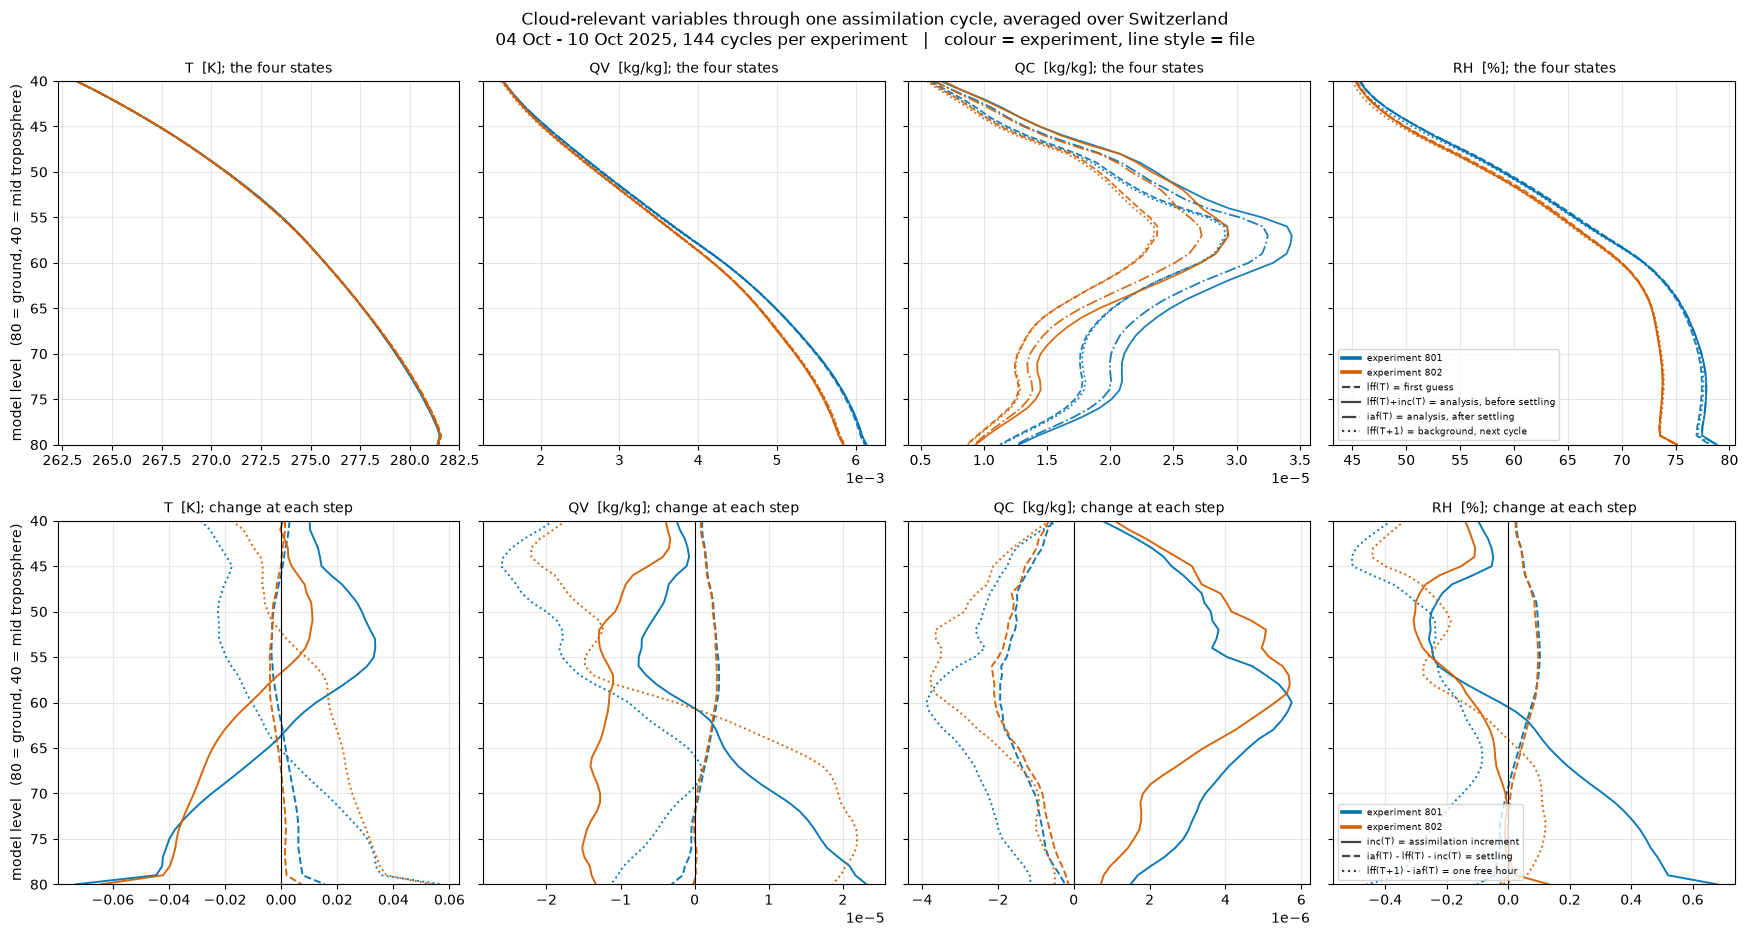

In [30]:
# Top row: the four states. Bottom row: the three steps between them.
fig, axes = plt.subplots(2, len(PLOT_VARS), figsize=(4.4 * len(PLOT_VARS), 9.5), sharey=True)

for col, var in enumerate(PLOT_VARS):
    ax = axes[0, col]
    for exp_id in EXP_IDS:
        for stage in STAGES:
            ls, _ = STAGE_STYLE[stage]
            ax.plot(state_prof[(exp_id, stage, var)], lev, ls,
                    color=EXP_COLOUR[exp_id], lw=1.3, alpha=0.9)
    ax.set_title(f"{var}  [{VAR_UNITS[var]}]; the four states", fontsize=10)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")
    orient_vertical(ax, lev)

    ax = axes[1, col]
    for exp_id in EXP_IDS:
        for term in TERMS:
            ls, _ = TERM_STYLE[term]
            ax.plot(term_prof[(exp_id, term, var)], lev, ls,
                    color=EXP_COLOUR[exp_id], lw=1.4, alpha=0.95)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_title(f"{var}  [{VAR_UNITS[var]}]; change at each step", fontsize=10)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3), axis="x")
    orient_vertical(ax, lev)

axes[0, 0].set_ylabel(LEVEL_LABEL)
axes[1, 0].set_ylabel(LEVEL_LABEL)
style_legend(axes[0, -1], STAGE_STYLE, fontsize=6.5, loc="lower left")
style_legend(axes[1, -1], TERM_STYLE, fontsize=6.5, loc="lower left")
plt.suptitle("Cloud-relevant variables through one assimilation cycle, averaged over Switzerland\n"
             f"{period_tag(n_cycles)}   |   colour = experiment, line style = file")
plt.tight_layout()
finish(fig, "cycle_variables_profiles.png")


In [31]:
# Column-integrated water budget: how much water each step adds to or removes from the column.
budget = (budget_df
          .melt(id_vars=["exp", "time", "hour"], var_name="key", value_name="kg_m2")
          .assign(variable=lambda d: d["key"].str.split("_").str[0],
                  step=lambda d: d["key"].str.split("_", n=1).str[1])
          .groupby(["exp", "variable", "step"])["kg_m2"]
          .agg(mean="mean", std_error="sem", n="count")
          .reset_index())
budget["step"] = budget["step"].map({"d_letkf": "1 increment inc(T)",
                                     "d_settle": "2 settling",
                                     "d_free": "3 one free hour"})
budget = budget.sort_values(["variable", "step", "exp"]).reset_index(drop=True)
budget.to_csv(OUTPUT_DIR / "water_budget_summary.csv", index=False)
print("Column water budget over Switzerland [kg/m2 per cycle], "
      f"{period_tag(n_cycles)}\n"
      "QC = cloud water, QV = water vapour. Positive adds water.\n")
budget


Column water budget over Switzerland [kg/m2 per cycle], 04 Oct - 10 Oct 2025, 144 cycles per experiment
QC = cloud water, QV = water vapour. Positive adds water.



,exp,variable,step,mean,std_error,n
0,801,QC,1 increment inc(T),0.013464,0.001902,144
1,802,QC,1 increment inc(T),0.012843,0.002062,144
2,801,QC,2 settling,-0.005081,0.000706,144
3,802,QC,2 settling,-0.005178,0.000781,144
4,801,QC,3 one free hour,-0.008962,0.002374,144
5,802,QC,3 one free hour,-0.008343,0.002409,144
6,801,QV,1 increment inc(T),0.000992,0.011063,144
7,802,QV,1 increment inc(T),-0.036915,0.010923,144
8,801,QV,2 settling,0.006329,0.000796,144
9,802,QV,2 settling,0.006107,0.000863,144


## 3. Does the assimilation push air past saturation?

The mechanism most often suspected is that correcting screen-level temperature and humidity lifts
part of the near-surface air past saturation, so the model condenses it into cloud in the first
timesteps.

Because the increment is available, this can be tested with no model involvement at all: compare the
fraction of columns at or above saturation in `lff(T)` against the same fraction in
`lff(T)+inc(T)`. Any difference between those two is the assimilation alone. `iaf(T)` and `lff(T+1)`
then show what the model does with it.

This counts grid-scale saturation only, which is a lower bound on where cloud appears; the scheme
also makes partial cloud below 100% relative humidity from sub-grid variability.


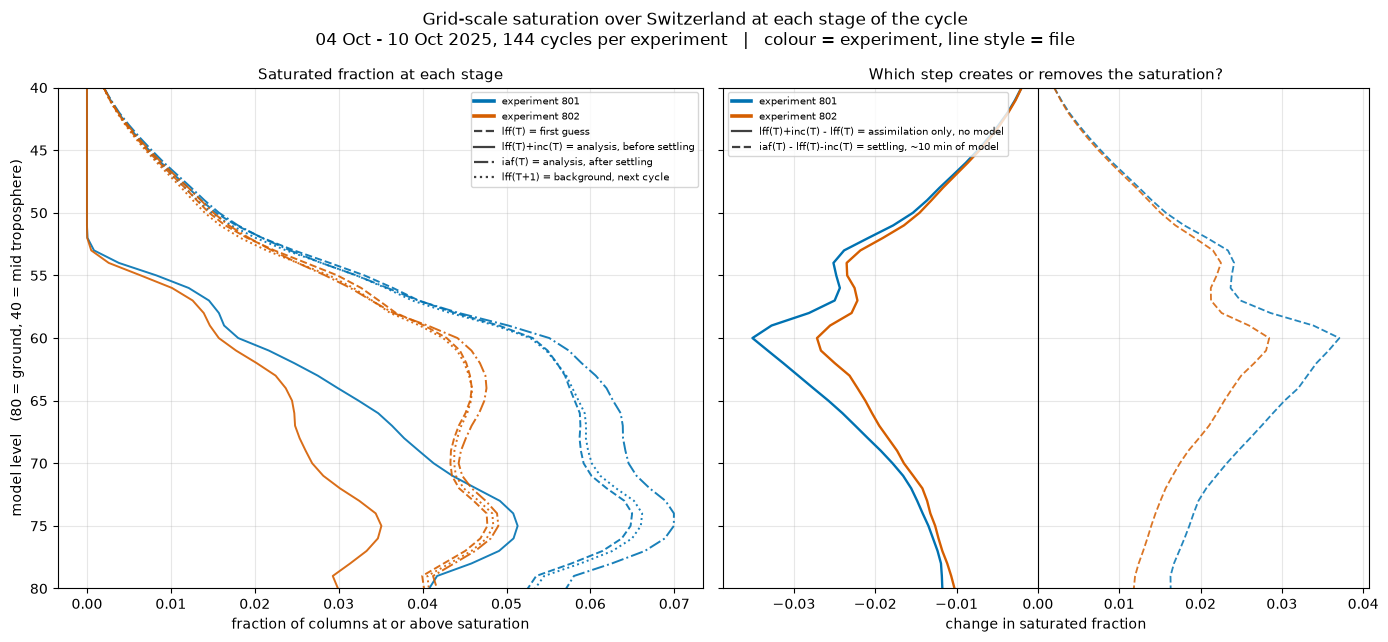

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), sharey=True)

for exp_id in EXP_IDS:
    for stage in STAGES:
        ls, _ = STAGE_STYLE[stage]
        axes[0].plot(sat_frac[(exp_id, stage)], lev, ls,
                     color=EXP_COLOUR[exp_id], lw=1.4, alpha=0.9)
axes[0].set_xlabel("fraction of columns at or above saturation")
axes[0].set_ylabel(LEVEL_LABEL)
axes[0].set_title("Saturated fraction at each stage", fontsize=11)
axes[0].grid(alpha=0.3)
style_legend(axes[0], STAGE_STYLE, fontsize=7, loc="upper right")

# Split into the assimilation-only part and the settling part.
SPLIT_STYLE = {
    "assim":  ("-",  "lff(T)+inc(T) - lff(T) = assimilation only, no model"),
    "settle": ("--", "iaf(T) - lff(T)-inc(T) = settling, ~10 min of model"),
}
for exp_id in EXP_IDS:
    axes[1].plot(sat_frac[(exp_id, "laf")] - sat_frac[(exp_id, "lff")], lev,
                 SPLIT_STYLE["assim"][0], color=EXP_COLOUR[exp_id], lw=1.7)
    axes[1].plot(sat_frac[(exp_id, "iaf")] - sat_frac[(exp_id, "laf")], lev,
                 SPLIT_STYLE["settle"][0], color=EXP_COLOUR[exp_id], lw=1.3, alpha=0.85)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("change in saturated fraction")
axes[1].set_title("Which step creates or removes the saturation?", fontsize=11)
axes[1].grid(alpha=0.3)
style_legend(axes[1], SPLIT_STYLE, fontsize=7, loc="upper left")

for ax in axes:
    orient_vertical(ax, lev)
plt.suptitle("Grid-scale saturation over Switzerland at each stage of the cycle\n"
             f"{period_tag(n_cycles)}   |   colour = experiment, line style = file")
plt.tight_layout()
finish(fig, "saturation_by_stage.png")


## 4. Where in space does the assimilation put its corrections?

The averages above answer "how much" but not "where". These two views show the **mean assimilation
increment**, `inc(T)`, the observation-driven correction with no model in it, averaged over every
cycle in the period, for temperature, water vapour and cloud water, and for both experiments side by
side.

- **4a, horizontal:** the lowest model layer, the one touching the ground. Country borders are drawn
  for orientation and the line of the vertical section is marked.
- **4b, vertical:** a west-to-east section along that line, plotted against real altitude with the
  terrain filled in, which shows whether a correction is confined beneath an inversion. The line runs
  from Lake Geneva through **Payerne** to St. Gallen; Payerne is marked because it is the radiosonde
  site the soundings in this project come from.

Each variable gets its own colour scale, shared between the two experiments so they can be compared
directly. Red means the correction adds, blue means it removes.


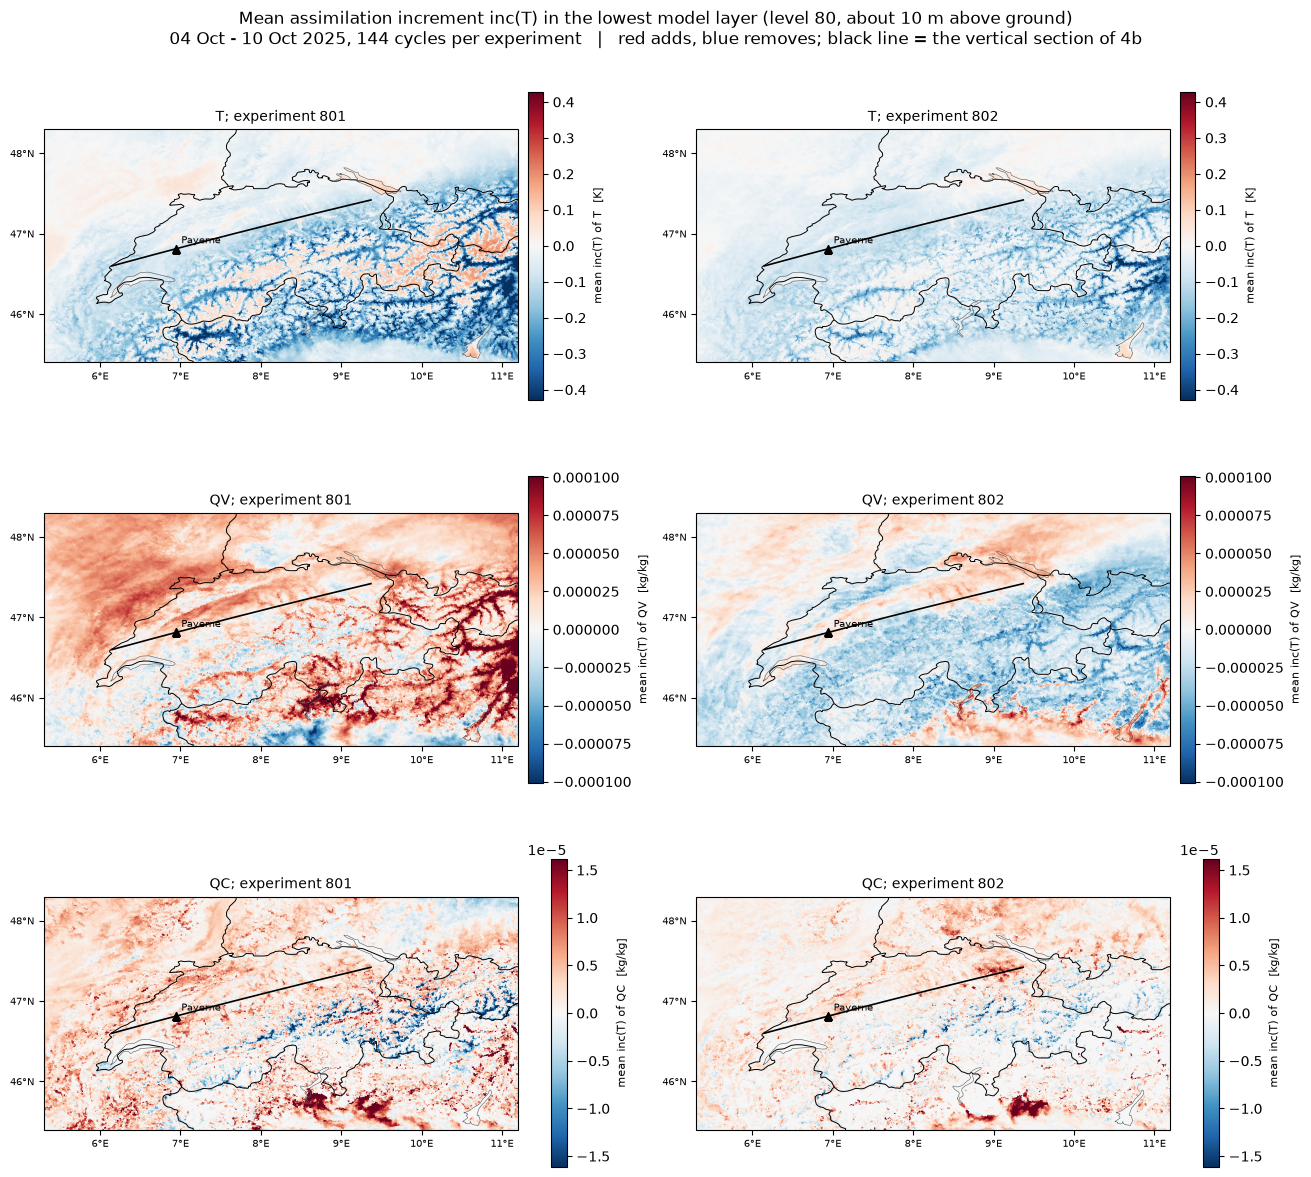

In [33]:
def sym_limit(arrays, pct=99.0):
    """One symmetric colour limit shared across panels, so magnitudes stay comparable."""
    vals = np.concatenate([np.abs(a[np.isfinite(a)]).ravel() for a in arrays])
    v = np.nanpercentile(vals, pct) if vals.size else 1.0
    return v if v > 0 else 1.0


# ---------------------- 4a. lowest model layer, with borders ----------------------
mbox = in_box(geom["lon"], geom["lat"], MAP_BOX)
mlon, mlat = geom["lon"][mbox], geom["lat"][mbox]

fig, axes = plt.subplots(len(DIAG_VARS), len(EXP_IDS), figsize=(13, 12),
                         subplot_kw={"projection": ccrs.PlateCarree()},
                         constrained_layout=True)
for r, var in enumerate(DIAG_VARS):
    vlim = sym_limit([inc_ground[(e, var)][mbox] for e in EXP_IDS])
    for c, exp_id in enumerate(EXP_IDS):
        ax = axes[r, c]
        sc = ax.scatter(mlon, mlat, c=inc_ground[(exp_id, var)][mbox], s=1.6,
                        cmap="RdBu_r", vmin=-vlim, vmax=vlim, linewidths=0,
                        transform=ccrs.PlateCarree())
        ax.set_extent([MAP_BOX["lon"][0], MAP_BOX["lon"][1],
                       MAP_BOX["lat"][0], MAP_BOX["lat"][1]], crs=ccrs.PlateCarree())
        add_borders(ax)
        ax.plot(lon_t, lat_t, "k-", lw=1.2, transform=ccrs.PlateCarree())
        ax.plot(*PAYERNE[::-1], "k^", ms=6, transform=ccrs.PlateCarree())
        ax.annotate("Payerne", xy=PAYERNE[::-1], xytext=(4, 4), textcoords="offset points",
                    fontsize=7, transform=ccrs.PlateCarree())
        cb = plt.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
        cb.set_label(f"mean inc(T) of {var}  [{VAR_UNITS[var]}]", fontsize=8)
        ax.set_title(f"{var}; experiment {exp_id}", fontsize=10)
        # explicit ticks rather than gridlines(draw_labels=...): the labelled gridliner
        # clashes with a tight bounding box on cartopy axes
        ax.set_xticks(np.arange(6, 12, 1), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(46, 49, 1), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=7)

plt.suptitle("Mean assimilation increment inc(T) in the lowest model layer "
             f"(level {GROUND_LEVEL}, about 10 m above ground)\n"
             f"{period_tag(n_cycles)}   |   red adds, blue removes; "
             "black line = the vertical section of 4b")
finish(fig, "increment_map_ground_level.png")


section length 261 km; Payerne at 65 km along it, 0.4 km off the line


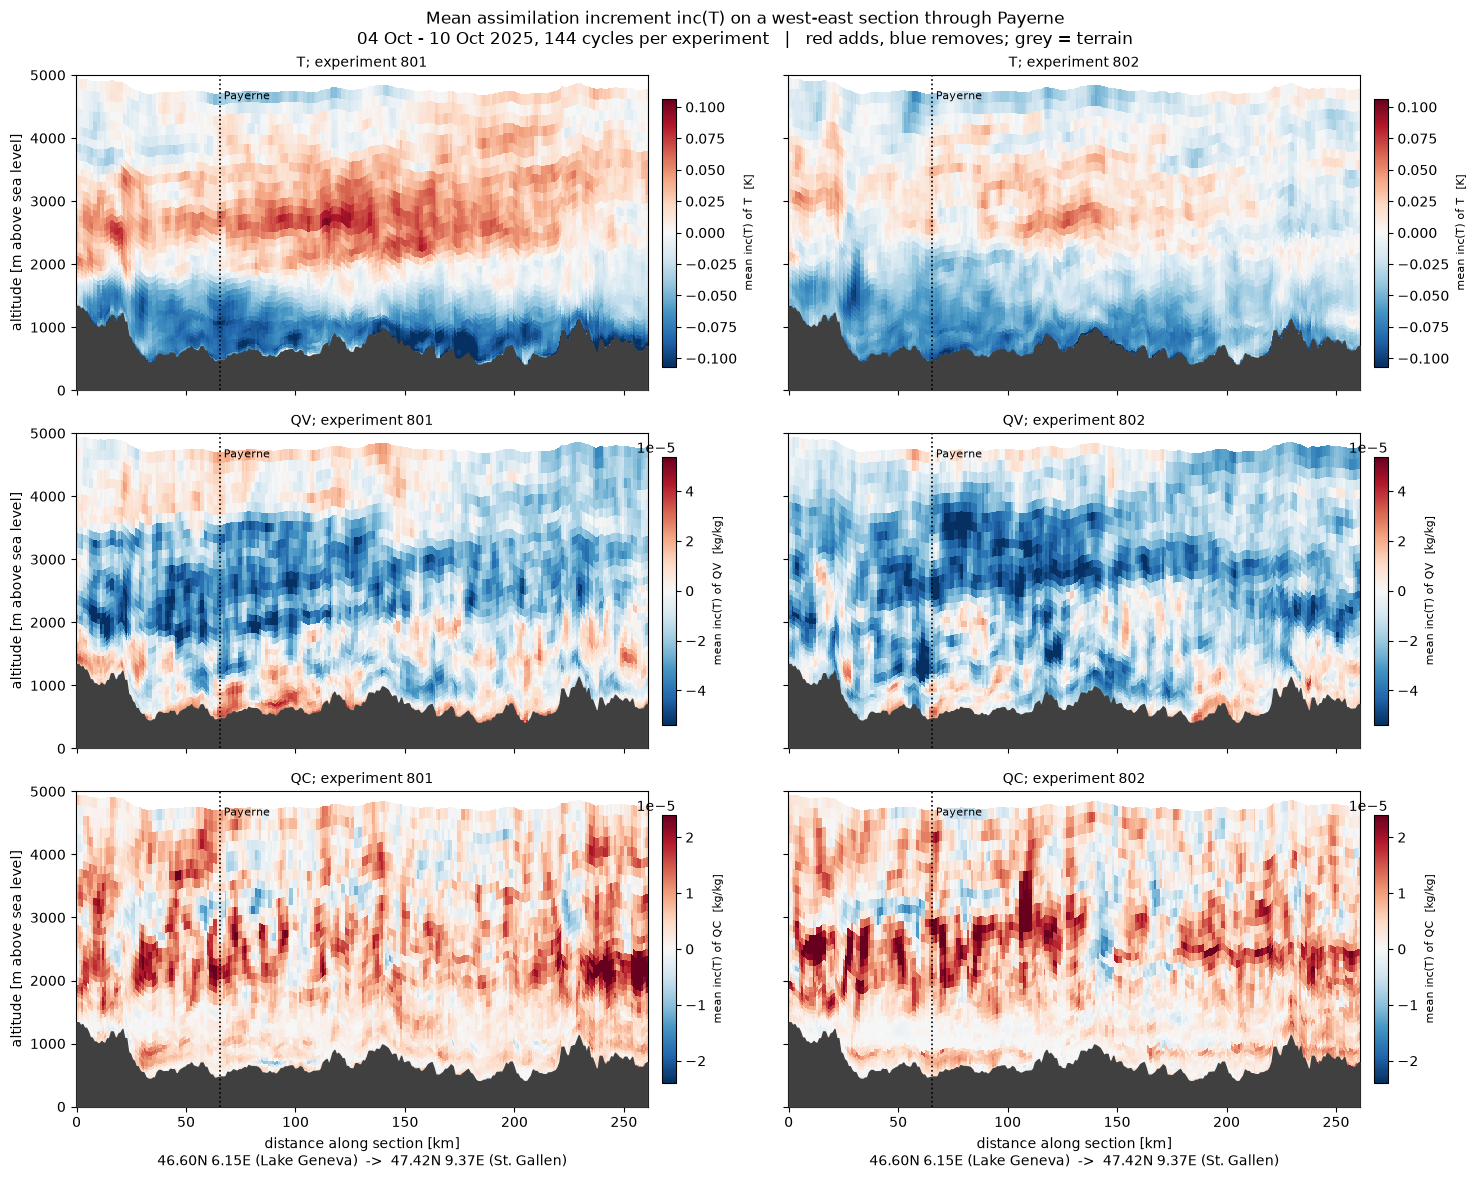

In [34]:
# ---------------------- 4b. vertical section through Payerne ----------------------
z_sec = geom["z"][:, geom["t_idx"]]
terrain = geom["hsurf"][geom["t_idx"]]
dist2d = np.broadcast_to(dist_t, z_sec.shape)

# where Payerne sits along the section
d_pay = np.hypot(np.deg2rad(lat_t - PAYERNE[0]) * 6371.0,
                 np.deg2rad(lon_t - PAYERNE[1]) * 6371.0 * np.cos(np.deg2rad(PAYERNE[0])))
i_pay = int(np.argmin(d_pay))
print(f"section length {dist_t[-1]:.0f} km; Payerne at {dist_t[i_pay]:.0f} km "
      f"along it, {d_pay[i_pay]:.1f} km off the line")

fig, axes = plt.subplots(len(DIAG_VARS), len(EXP_IDS), figsize=(15, 12),
                         sharex=True, sharey=True)
for r, var in enumerate(DIAG_VARS):
    vlim = sym_limit([inc_section[(e, var)] for e in EXP_IDS])
    for c, exp_id in enumerate(EXP_IDS):
        ax = axes[r, c]
        pc = ax.pcolormesh(dist2d, z_sec, inc_section[(exp_id, var)], shading="auto",
                           cmap="RdBu_r", vmin=-vlim, vmax=vlim)
        ax.fill_between(dist_t, 0, terrain, color="0.25", zorder=5)
        ax.axvline(dist_t[i_pay], color="k", ls=":", lw=1.2, zorder=6)
        ax.text(dist_t[i_pay], SECTION_ZTOP * 0.95, " Payerne", fontsize=8,
                va="top", ha="left", zorder=7)
        cb = plt.colorbar(pc, ax=ax, shrink=0.85, pad=0.02)
        cb.set_label(f"mean inc(T) of {var}  [{VAR_UNITS[var]}]", fontsize=8)
        ax.set_title(f"{var}; experiment {exp_id}", fontsize=10)
        ax.set_ylim(0, SECTION_ZTOP)
        if r == len(DIAG_VARS) - 1:
            ax.set_xlabel(f"distance along section [km]\n"
                          f"{TRANSECT[0][0]:.2f}N {TRANSECT[0][1]:.2f}E (Lake Geneva)"
                          f"  ->  {TRANSECT[1][0]:.2f}N {TRANSECT[1][1]:.2f}E (St. Gallen)")
        if c == 0:
            ax.set_ylabel("altitude [m above sea level]")

plt.suptitle("Mean assimilation increment inc(T) on a west-east section through Payerne\n"
             f"{period_tag(n_cycles)}   |   red adds, blue removes; grey = terrain")
plt.tight_layout()
finish(fig, "increment_section_payerne.png")


## 5. Summary

### Output files

All written to `figures/spindown_decomposition/`.

| file | contents |
|---|---|
| `diurnal_boxplots_801.png`, `diurnal_boxplots_802.png` | cloud cover by hour of day, background against analysis |
| `diurnal_boxplots_801_vs_802_lff.png`, `..._iaf.png` | the two experiments compared directly, one figure per file |
| `cloud_cover_timeseries.png` | mean cloud cover through the period |
| `cycle_variables_profiles.png` | T, QV, QC, RH: the four states and the three steps |
| `saturation_by_stage.png` | saturated fraction, and which step changes it |
| `increment_map_ground_level.png` | mean increment in the lowest layer, with borders |
| `increment_section_payerne.png` | mean increment on a section through Payerne |
| `cloud_cover_means.csv`, `water_budget_per_cycle.csv`, `water_budget_summary.csv` | the numbers behind the figures |

### How to read the results

- Colour is always the experiment; line style is always the file. A legend entry names the file, so
  no panel needs this text to be interpreted.
- Every average and distribution is taken over the same Swiss box, so numbers are comparable between
  sections.
- The increment is the only quantity with no model in it. Settling and the free hour both mix
  assimilation and model response, so mechanism claims should rest on the increment.
- A difference in cloud cover between the two experiments says which is *cloudier*, not which is
  *better*. Observations are needed for that and none enter this notebook.

### Known limitations

- **`lff(T+1) - iaf(T)` is partly constrained by arithmetic.** The next background of one cycle is
  the background of the next, so over a long period what the assimilation adds and what the following
  hour removes must nearly cancel, whatever the physics. Treat that step as descriptive.
- The lowest model layer sits about 10 m above ground, so the horizontal map is a near-surface view,
  not a screen-level one.
- Cloud ice is never corrected by the assimilation, so its increment is zero by construction and the
  split says nothing about ice cloud.
- The period covers one to two weather regimes. A signal that is systematic here need not be
  systematic across seasons.
